## 1. Data Exploration

Checks: number of images/classes, image dimensions, corrupted/duplicate files, class imbalance, label ↔ folder alignment, visual sanity check.
Then: stratified train/val/test split (per-class, fixed seed) + a manifest CSV.

In [8]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

RAW = Path("../data/raw")
CLASSES_CSV = RAW / "classes.csv"
SPLIT_DIR = Path("../data/splits")
SPLIT_RATIO = (0.715, 0.16, 0.125)  # train / val / test
SEED = 1337
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}  # compared in lowercase

### Index every image and attach labels by *name* (not by row position)

In [9]:
rows = [{"path": p, "name": p.parent.name} for p in RAW.glob("*/*") if p.suffix.lower() in IMG_EXTS]
df = pd.DataFrame(rows)

classes = pd.read_csv(CLASSES_CSV)
df = df.merge(classes, on="name", how="left", validate="m:1")

assert df["label"].notna().all(), "image folder missing from classes.csv"
assert set(classes["name"]) == set(df["name"]), "classes.csv lists a folder with no images"
# Keras assigns class index by sorted folder name, so classes.csv must follow the same order.
assert list(classes.sort_values("label")["name"]) == sorted(classes["name"]), "label order != alphabetical"

counts = df.groupby(["label", "name"]).size().rename("counts").reset_index()
print(f"{len(df)} images, {len(counts)} classes")
print(f"per class: min={counts.counts.min()}  median={counts.counts.median():.0f}  max={counts.counts.max()}")
counts

1236 images, 21 classes
per class: min=44  median=60  max=60


,label,name,counts
0,0,005.Crested_Auklet,44
1,1,013.Bobolink,60
2,2,015.Lazuli_Bunting,58
3,3,023.Brandt_Cormorant,59
4,4,040.Olive_sided_Flycatcher,60
5,5,041.Scissor_tailed_Flycatcher,60
6,6,067.Anna_Hummingbird,60
7,7,072.Pomarine_Jaeger,60
8,8,076.Dark_eyed_Junco,60
9,9,081.Pied_Kingfisher,60


### Integrity, dimensions, duplicates

In [10]:
def inspect(p):
    try:
        with Image.open(p) as im:
            im.verify()  # detects truncated/corrupt files
        with Image.open(p) as im:
            return im.width, im.height, im.mode, True
    except Exception:
        return None, None, None, False

df[["w", "h", "mode", "ok"]] = pd.DataFrame(df["path"].apply(inspect).tolist(), index=df.index)
df["md5"] = df["path"].apply(lambda p: hashlib.md5(p.read_bytes()).hexdigest())

print("corrupt files :", int((~df.ok).sum()))
print("exact dups    :", int(df.md5.duplicated(keep=False).sum()), "files involved")
print("non-RGB modes :", df["mode"].value_counts().to_dict(), "(Keras converts to RGB on load)")
print("smaller than 224px on a side:", int(((df.w < 224) | (df.h < 224)).sum()))
print(df[["w", "h"]].describe().round(0))

bad = df[~df.ok | df.md5.duplicated(keep=False)]
bad[["path", "ok"]]  # delete these files from data/raw BEFORE splitting (duplicates across splits = leakage)

corrupt files : 0
exact dups    : 0 files involved
non-RGB modes : {'RGB': 1236} (Keras converts to RGB on load)
smaller than 224px on a side: 8
            w       h
count  1236.0  1236.0
mean    472.0   387.0
std      59.0    69.0
min     170.0   120.0
25%     500.0   333.0
50%     500.0   374.0
75%     500.0   433.0
max     500.0   500.0


,path,ok


### Class balance and visual check

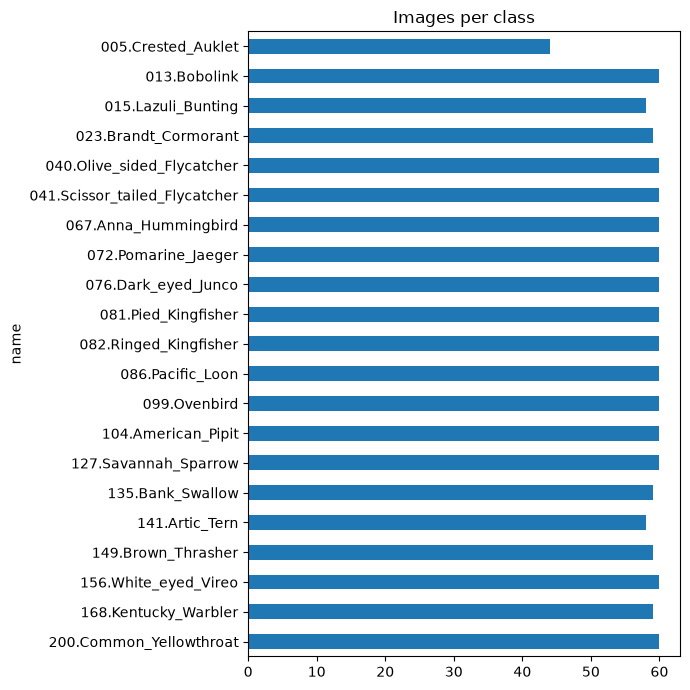

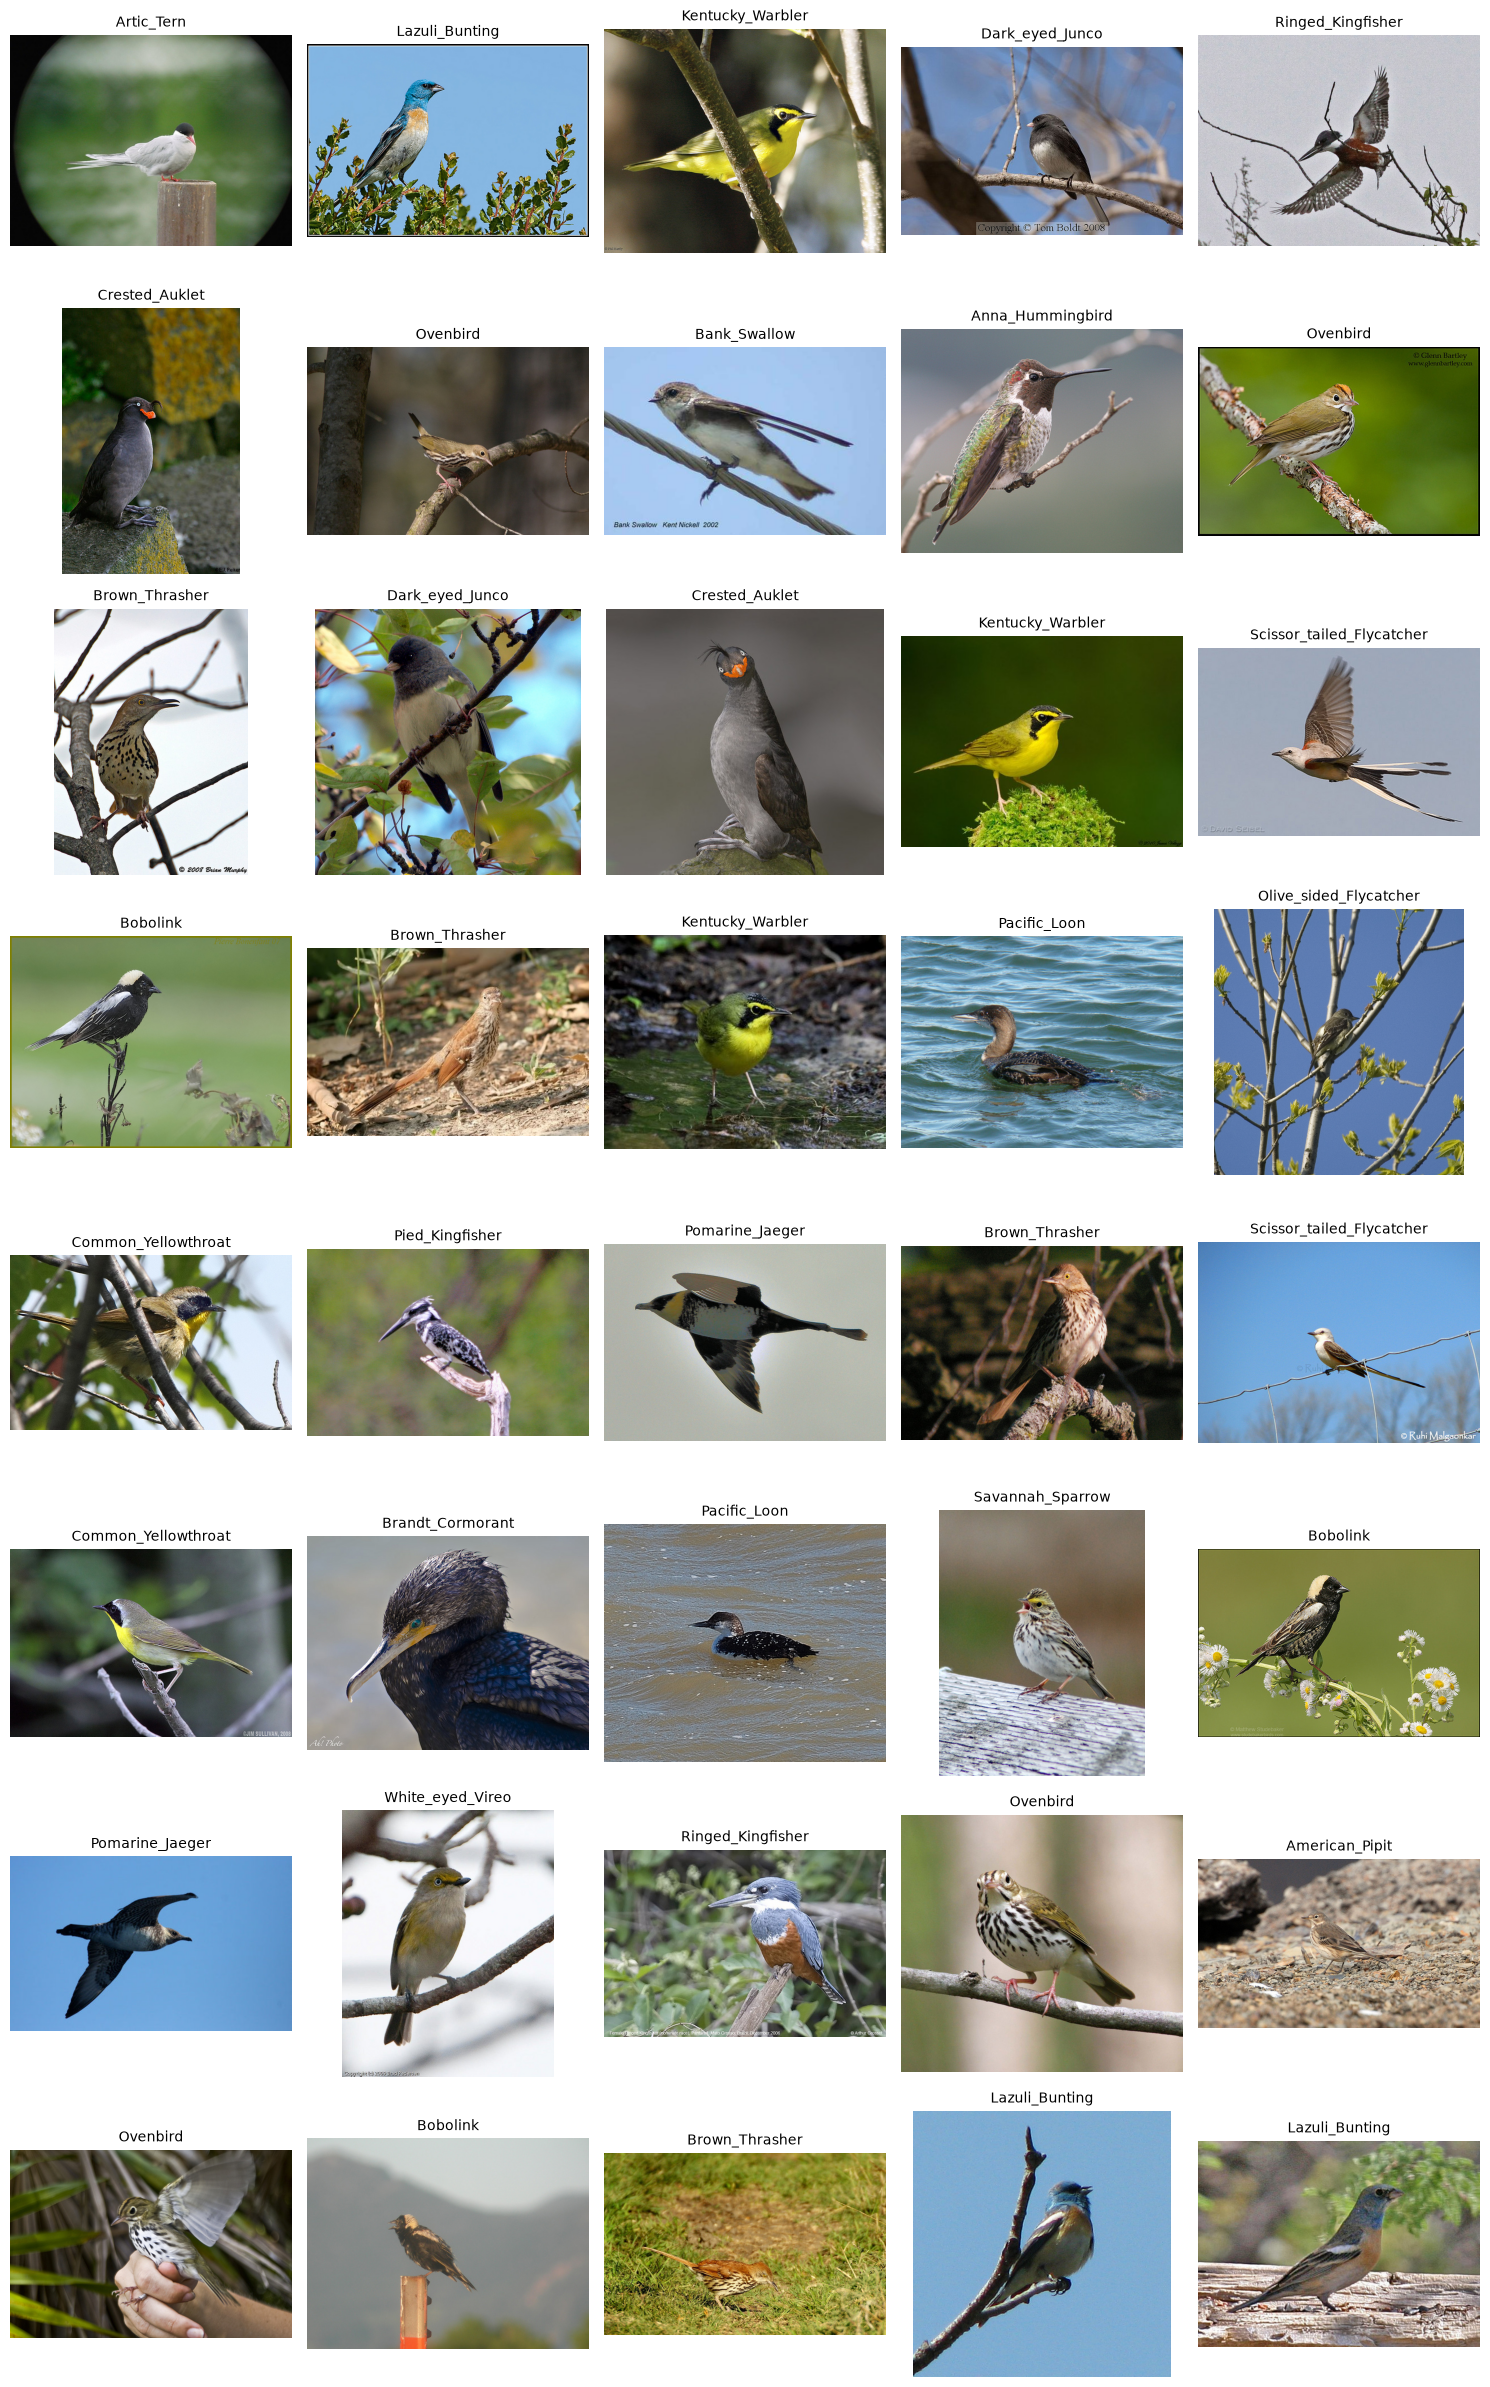

In [17]:
ax = counts.set_index("name")["counts"].plot.barh(figsize=(7, 7), title="Images per class")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

sample = df[df.ok].sample(40, random_state=0)
fig, axes = plt.subplots(8, 5, figsize=(15, 24))
for ax, (_, r) in zip(axes.ravel(), sample.iterrows()):
    ax.imshow(Image.open(r.path).convert("RGB")); ax.set_title(r["name"].split(".")[1], fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()
# Look for: multiple birds, tiny birds in the frame, illustrations, watermarks, wrong labels.

## 2. Dataset splits
Per-class split (so every species appears in all three sets). Only runs if `data/splits` does not exist yet.

In [18]:
import splitfolders

if SPLIT_DIR.exists():
    print(f"{SPLIT_DIR} already exists - skipping. Delete it to re-split.")
else:
    splitfolders.ratio(str(RAW), output=str(SPLIT_DIR), seed=SEED, ratio=SPLIT_RATIO)

..\data\splits already exists - skipping. Delete it to re-split.


In [20]:
# Manifest: a record of exactly which image went to which split.
manifest = pd.DataFrame(
    [{"split": p.parent.parent.name, "name": p.parent.name, "file": p.name}
     for p in SPLIT_DIR.glob("*/*/*") if p.suffix.lower() in IMG_EXTS]
)
manifest.to_csv("../data/splits_manifest.csv", index=False)

table = manifest.pivot_table(index="name", columns="split", values="file", aggfunc="count")[["train", "val", "test"]]
print(table.sum().to_dict(), "| smallest test class:", int(table.test.min()))
table

{'train': 869, 'val': 187, 'test': 180} | smallest test class: 6


split,train,val,test
name,,,
005.Crested_Auklet,31,7,6
013.Bobolink,42,9,9
015.Lazuli_Bunting,41,9,8
023.Brandt_Cormorant,42,9,8
040.Olive_sided_Flycatcher,42,9,9
041.Scissor_tailed_Flycatcher,42,9,9
067.Anna_Hummingbird,42,9,9
072.Pomarine_Jaeger,42,9,9
076.Dark_eyed_Junco,42,9,9
